## Exercise 3: Experimental setup

We trained a multilayer perceptron to classify handwritten digits from 0 to 9.
Each image contains 784 pixel values, which form the input to the network.
The predicted class is the output with the highest activation.

We split `more_digits.csv` into 80% training data and 20% validation data
using a stratified split with seed 0. Stratification preserves approximately
the same class proportions in both subsets. All stratified experiments
used the same validation split.

We compared network architectures, learning rates, optimizers, activation
parameters, batch sizes and training durations. We also evaluated three
changes to the training data:

- Adding unique images from `digits.csv`, excluding images already present
  in the training or validation set.
- Oversampling the training set by repeating examples from smaller classes.
- Adding one randomly shifted copy of each training image, using a
  one-pixel translation up, down, left or right with zero padding.

When combined, additional data was added first, followed by oversampling
and augmentation. Validation and test data were not oversampled or augmented.

The selected model used hidden layers [256, 128], Adam with a learning rate
of 0.0005, sigmoid activation with beta = 1.0, a batch size of 32,
and 30 training epochs.

Configurations were compared using validation results. Evaluation on
`digits_test.csv` and its limitations are discussed in Sections 3a and 3c.

The sequential baseline uses a different validation split and should be
interpreted separately from the stratified experiments.

In [1]:
from pathlib import Path
import json
import pandas as pd

# Works when the notebook runs from the project root or notebooks/.
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

rows = []

for path in sorted((root / "results" / "ex3").rglob("*.json")):
    saved = json.loads(path.read_text())
    config = saved["config"]
    result = saved["result"]
    extra = config.get("extra", {})

    rows.append({
        "experiment": path.parent.name,
        "layers": str(config["hidden_layers"]),
        "optimizer": config["optimizer_method"],
        "learning_rate": config["learning_rate"],
        "epochs": config["epochs"],
        "split": extra.get("split", "sequential"),
        "extra_data": bool(extra.get("extra_dataset")),
        "oversampling": extra.get("oversample", False),
        "accuracy_percent": 100 * result["accuracy"],
        "final_valid_loss": result["valid_loss"][-1],
        "seconds": result["total_seconds"],
        "activation_parameter": config["activation_parameter"],
        "augmentation": extra.get("augment", False),
    })

results = pd.DataFrame(rows).sort_values(
    "accuracy_percent", ascending=False
)

results = results[
    ~results["experiment"].isin([
        "best_saved",
        "ex2_config_baseline_saved",
    ])
]

display(results.round(4))

,experiment,layers,optimizer,learning_rate,epochs,split,extra_data,oversampling,accuracy_percent,final_valid_loss,seconds,activation_parameter,augmentation
2,adam_beta1_augmented_30epochs,"[256, 128]",adam,0.0005,30,stratified,True,True,98.1581,0.0151,115.8082,1.0,True
0,adam_best_beta1,"[256, 128]",adam,0.0005,60,stratified,True,True,97.7771,0.0212,129.5350,1.0,False
1,adam_beta1_augmented,"[256, 128]",adam,0.0005,60,stratified,True,True,97.6183,0.0199,268.0737,1.0,True
7,adam_h256-128_extra_oversampled_60epochs,"[256, 128]",adam,0.0005,60,stratified,True,True,97.5865,0.0218,112.6899,0.5,False
6,adam_h256-128_extra_data_60epochs,"[256, 128]",adam,0.0005,60,stratified,True,False,97.4913,0.0217,90.0549,0.5,False
3,adam_beta1_lr000025,"[256, 128]",adam,0.0002,60,stratified,True,True,97.3960,0.0228,127.7049,1.0,False
5,adam_h256-128_extra_data,"[256, 128]",adam,0.0005,70,stratified,True,False,97.2055,0.0224,98.3680,0.5,False
16,ex2_config_baseline,[128],gradient_descent,1.0000,50,stratified,False,False,97.1419,0.0276,18.4024,1.0,False
9,adam_h256_extra_data,[256],adam,0.0005,70,stratified,True,False,97.1102,0.0252,88.9842,0.5,False
19,ex2_config_extra_oversampled,[128],gradient_descent,1.0000,50,stratified,True,True,97.0467,0.0255,40.3932,1.0,False


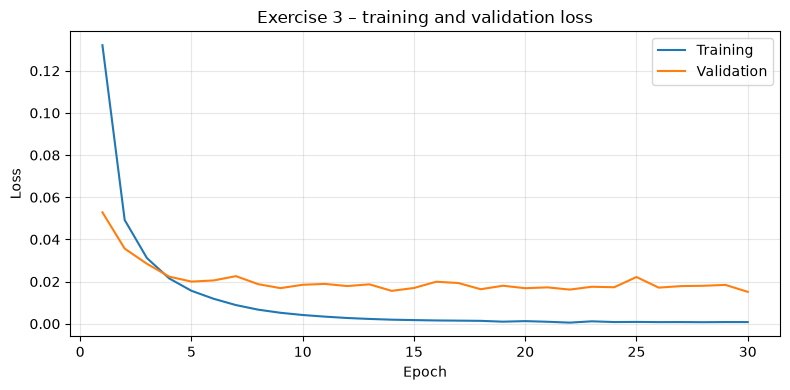

In [2]:
import matplotlib.pyplot as plt

best_path = next(
    (
        root / "results" / "ex3"
        / "adam_beta1_augmented_30epochs"
    ).glob("*.json")
)
saved = json.loads(best_path.read_text())
best_result = saved["result"]

epochs = range(1, len(best_result["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, best_result["train_loss"], label="Training")
plt.plot(epochs, best_result["valid_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Exercise 3 – training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Text(83.33333333333333, 0.5, 'Actual digit')

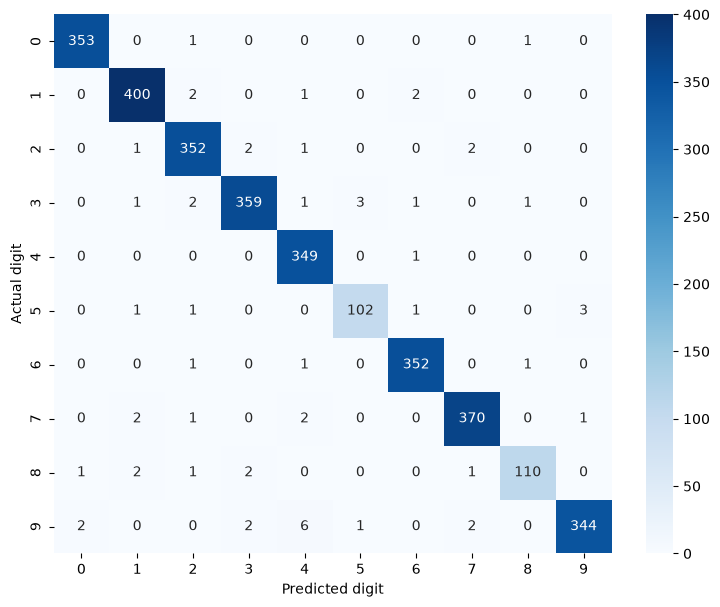

In [3]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(
    best_result["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10),
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")

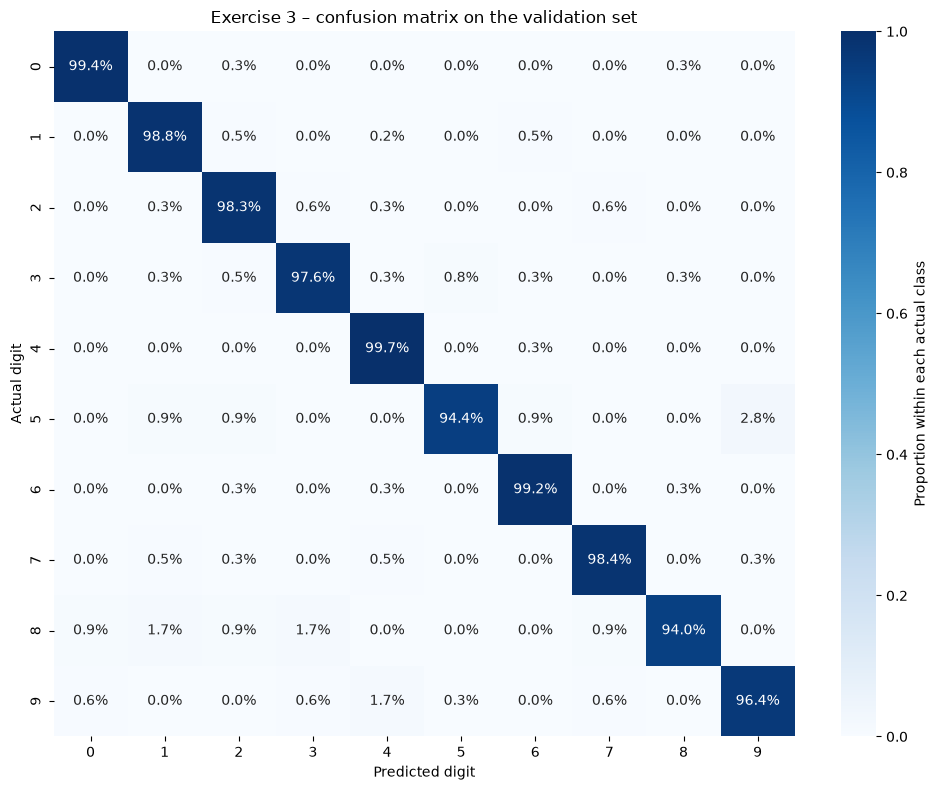

In [4]:
import numpy as np

cm = np.array(best_result["confusion_matrix"])
row_totals = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_totals,
    out=np.zeros_like(cm, dtype=float),
    where=row_totals != 0,
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=range(10),
    yticklabels=range(10),
    cbar_kws={"label": "Proportion within each actual class"},
)
plt.xlabel("Predicted digit")
plt.ylabel("Actual digit")
plt.title("Exercise 3 – confusion matrix on the validation set")
plt.tight_layout()
plt.show()

In [5]:
comparison = []

for experiment in [
    "ex2_config_baseline",
    "ex2_config_extra_data",
    "ex2_config_oversampled",
    "ex2_config_extra_oversampled",
    "adam_beta1_augmented_30epochs",
]:
    path = next((root / "results" / "ex3" / experiment).glob("*.json"))
    result = json.loads(path.read_text())["result"]

    comparison.append({
        "experiment": experiment,
        "accuracy_percent": 100 * result["accuracy"],
        "recall_5_percent": 100 * result["recall"][5],
        "recall_8_percent": 100 * result["recall"][8],
    })

display(pd.DataFrame(comparison).round(2))

,experiment,accuracy_percent,recall_5_percent,recall_8_percent
0,ex2_config_baseline,97.14,89.81,90.60
1,ex2_config_extra_data,96.95,87.96,82.91
2,ex2_config_oversampled,96.86,87.96,90.60
3,ex2_config_extra_oversampled,97.05,90.74,88.03
4,adam_beta1_augmented_30epochs,98.16,94.44,94.02


In [6]:
from perceptrons.experiment import load_model
from perceptrons.data import load_digits, one_hot_decode
from perceptrons.metrics import accuracy, confusion_matrix, recall

model_path = next(
    (
        root / "results" / "ex3"
        / "adam_beta1_augmented_30epochs"
    ).glob("*.npz")
)
model, config = load_model(model_path)

X_test, Y_test = load_digits(root / "data" / "digits_test.csv")
Y_pred = one_hot_decode(model.forward(X_test))

test_cm = confusion_matrix(Y_test, Y_pred, config.n_classes)

print(f"Test accuracy: {accuracy(test_cm):.2%}")

display(pd.DataFrame({
    "digit": range(config.n_classes),
    "test_recall_percent": 100 * np.array(recall(test_cm)),
}).round(2))

Test accuracy: 98.12%


,digit,test_recall_percent
0,0,99.18
1,1,98.94
2,2,98.45
3,3,99.60
4,4,100.00
5,5,96.41
6,6,98.33
7,7,98.44
8,8,95.88
9,9,95.63


## 3a – Best result with the new dataset

The selected model achieved **98.16% validation accuracy** and
**98.12% test accuracy** on `digits_test.csv`. It therefore met the
requested threshold of at least 98% on the provided test set.

The selected configuration was:

| Parameter | Value |
|---|---|
| Hidden layers | [256, 128] |
| Optimizer | Adam |
| Learning rate | 0.0005 |
| Activation | Sigmoid, beta = 1.0 |
| Batch size | 32 |
| Epochs | 30 |
| Random seed | 0 |

We used a stratified 80/20 split of `more_digits.csv`. Additional unique
images from `digits.csv` were added only to the training set, excluding
duplicates against both training and validation images.

The training set was then balanced through oversampling. Data augmentation
added one randomly shifted copy of each training image, using a one-pixel
shift up, down, left or right. Validation and test images were not augmented.

Test recall was 96.41% for digit 5 and 95.88% for digit 8.
Digit 9 had the lowest test recall, at 95.63%.

These results describe one run with seed 0. They do not establish that
accuracy will remain above 98% across other seeds or future datasets.


## 3b – Techniques evaluated to improve performance

We first applied the selected Exercise 2 configuration to `more_digits.csv`
to establish a baseline. It achieved 97.14% validation accuracy.

Keeping that configuration fixed, we evaluated changes to the training data:

| Training-data variant | Validation accuracy |
|---|---:|
| Baseline | 97.14% |
| Additional unique images | 96.95% |
| Oversampling | 96.86% |
| Additional images and oversampling | 97.05% |

These changes did not improve overall accuracy with the baseline
configuration and seed 0.

We then explored different architectures, optimizers, learning rates,
activation parameters and training durations. A configuration using Adam,
hidden layers [256, 128], additional data and oversampling achieved 97.59%
validation accuracy with beta = 0.5. Changing only beta to 1.0 increased
accuracy to 97.78%.

Finally, we introduced one-pixel translation augmentation:

| Selected Adam configuration | Validation accuracy |
|---|---:|
| Without augmentation, 60 epochs | 97.78% |
| With augmentation, 60 epochs | 97.62% |
| With augmentation, 30 epochs | 98.16% |

In the augmented 60-epoch run, validation loss decreased initially and
then increased while training loss remained low. This suggested
overfitting during later training. We therefore evaluated a 30-epoch
run, which achieved the highest observed validation accuracy.

Augmentation combined with the shorter training duration produced the
best result among the evaluated configurations. However, augmentation
and oversampling also increase the number of weight updates per epoch.
The improvement cannot be attributed solely to image variation or
class balancing.

## 3c – Other factors affecting the change in performance

An important difference between the datasets is class coverage:
`digits.csv` contains no examples of digit 8, whereas `more_digits.csv`
includes all ten digit classes. The original dataset contains 12,449
images, while the new dataset contains 15,741 images.

The Exercise 2 models achieved a mean test accuracy of 86.61% across
three seeds and 0% recall for digit 8. Using the same hyperparameters
on the new dataset, the Exercise 3 baseline achieved 96.08% test accuracy
and 90.95% recall for digit 8 with seed 0.

This comparison suggests that the improved training data contributed
substantially to performance before introducing the additional techniques.
However, it compares a three-seed mean with a single run, and multiple
dataset properties changed simultaneously.

Class imbalance remains relevant. Digits 5 and 8 are less represented
than most other classes. The test set also has a different class
distribution from the validation set, so overall accuracy depends partly
on the proportion of each class.

The original and new training datasets overlap. We excluded duplicate
images when adding data and excluded additional images already present
in the validation set to avoid direct leakage.

### Evaluation limitations

Configurations were compared using validation results. However, the test
set was evaluated for earlier models before development was complete.
The final 98.12% result is therefore a follow-up evaluation on a previously
observed test set, rather than a completely untouched final evaluation.

Repeated adaptive comparisons on the same validation split can also
produce optimistic estimates. Further evaluation across seeds and on
fresh unseen data would strengthen the conclusions.